## Preprocessing

In [1]:
import pandas as pd
import numpy as np

In [2]:
cols = ['Unnamed: 0',
 'Flow ID',
 'Src IP',
 'Src Port',
 'Dst IP',
 'Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd Byts/b Avg',
 'Fwd Pkts/b Avg',
 'Fwd Blk Rate Avg',
 'Bwd Byts/b Avg',
 'Bwd Pkts/b Avg',
 'Bwd Blk Rate Avg',
 'Subflow Fwd Pkts',
 'Subflow Fwd Byts',
 'Subflow Bwd Pkts',
 'Subflow Bwd Byts',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Active Max',
 'Active Min',
 'Idle Mean',
 'Idle Std',
 'Idle Max',
 'Idle Min',
 'Label']

In [2]:
chunks = []
random_data_for_demo = []
chunk_size = 100000

for chunk_idx, chunk in enumerate(pd.read_csv("/kaggle/input/ddos-datasets/ddos_balanced/final_dataset.csv", chunksize=chunk_size)):
    chunk_ = chunk.sample(frac=0.25, random_state=42)
    random_ = chunk.sample(frac=0.01, random_state=42)
    
    chunks.append(chunk_)
    random_data_for_demo.append(random_)
    
    if chunk_idx%10 == 0:
        print(f"Chunk {chunk_idx} done")
print("Complete")

Chunk 0 done
Chunk 10 done
Chunk 20 done
Chunk 30 done
Chunk 40 done
Chunk 50 done
Chunk 60 done
Chunk 70 done
Chunk 80 done
Chunk 90 done
Chunk 100 done
Chunk 110 done
Chunk 120 done
Complete


In [3]:
df = pd.concat(chunks, ignore_index=True)
del chunks

df.to_parquet('/kaggle/working/sample_data.parquet', index=False)
print("Wrote file")

Wrote file


In [4]:
df_for_demo = pd.concat(random_data_for_demo, ignore_index=True)
del random_data_for_demo

df_for_demo.to_csv("/kaggle/working/data_for_demo.csv")
print("Wrote file")

Wrote file


In [5]:
df["Label"].value_counts()

Label
ddos      1618198
Benign    1580459
Name: count, dtype: int64

Wrote file


Uncomment to load the file

In [56]:
# df = pd.read_parquet("/kaggle/working/sample_data.parquet")

In [6]:
df.head()

,Unnamed: 0,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22165,172.31.69.25-18.219.211.138-80-34408-6,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,26628,172.31.69.25-18.219.211.138-80-40676-6,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,76682,192.168.2.109-203.73.24.75-4020-80-6,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,23143,172.31.69.25-18.219.211.138-80-36102-6,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,39435,172.31.69.25-18.219.211.138-80-44284-6,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [ ]:
df.columns.tolist()

In [7]:
df.drop(columns=["Unnamed: 0", "Flow ID"], inplace=True)

In [8]:
df.head()

,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18.219.211.138,34408,172.31.69.25,80,6,15/02/2018 07:24:59 PM,5032233,3,5,603.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
1,18.219.211.138,40676,172.31.69.25,80,6,15/02/2018 07:26:24 PM,10993127,3,5,408.0,...,0,783.0,0.0,783.0,783.0,5990709.0,0.0,5990709.0,5990709.0,ddos
2,192.168.2.109,4020,203.73.24.75,80,6,12/06/2010 03:12:15 PM,479425,3,7,142.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos
3,18.219.211.138,36102,172.31.69.25,80,6,15/02/2018 07:08:53 PM,9042123,1,1,0.0,...,0,0.0,0.0,0.0,0.0,9042123.0,0.0,9042123.0,9042123.0,ddos
4,18.219.211.138,44284,172.31.69.25,80,6,15/02/2018 07:19:56 PM,1907579,1,1,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ddos


In [9]:
# Convert IP strings into octets efficiently using NumPy
def ip_to_octets(ip_series, prefix):
    octets = np.stack(ip_series.str.split('.').apply(lambda x: list(map(int, x))))
    return pd.DataFrame(octets, columns=[f"{prefix} Octet{i+1}" for i in range(4)])

In [10]:
# Apply the optimized function
src_octets = ip_to_octets(df["Src IP"], "Src IP")
dst_octets = ip_to_octets(df["Dst IP"], "Dst IP")

# Concatenate with original DataFrame
df = pd.concat([df, src_octets, dst_octets], axis=1).drop(columns=["Src IP", "Dst IP"])

# Done
print("IP segmentation Done")

# Delete unused vars
del src_octets
del dst_octets

IP segmentation Done


In [11]:
columns_with_nan = df.columns[df.isnull().any()]

for col in columns_with_nan:
    print(f"Column '{col}' has {df[col].isnull().sum()} NaN values")

Column 'Flow Byts/s' has 7421 NaN values


In [12]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [13]:
df = pd.DataFrame(df.dropna(), columns=df.columns)

In [14]:
y = df["Label"]
X = df.drop(columns=["Label"])

In [15]:
print(y.isnull().any().sum())
print(X.isnull().any().sum())

0
0


In [16]:
y.nunique()

2

In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [18]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
non_numerical_cols = X.select_dtypes(exclude=np.number).columns.tolist()
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0
0
0


In [19]:
non_numerical_cols

['Timestamp']

In [20]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="mean")

train_X[numerical_cols] = pd.DataFrame(imputer.fit_transform(train_X[numerical_cols]), columns=numerical_cols, index=train_X.index)  # DO NOT remove the index=xxx attribute, else NaN happens
test_X[numerical_cols] = pd.DataFrame(imputer.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Imputing complete")

0
0
Imputing complete


In [21]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_X[numerical_cols])
train_X[numerical_cols] = pd.DataFrame(train_scaled, columns=numerical_cols, index=train_X.index)
test_X[numerical_cols] = pd.DataFrame(scaler.transform(test_X[numerical_cols]), columns=numerical_cols, index=test_X.index)

print(train_X.isnull().any(axis=1).sum())
print(test_X.isnull().any(axis=1).sum())

print("Scaling complete")

0
0
Scaling complete


In [24]:
import joblib
# Store imputer & scaler
joblib.dump(imputer, 'imputer.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Saved prep models")

Saved prep models


In [25]:
train_X.head()
train_X.shape

(2549400, 88)

In [26]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
2969617,0.775326,0.000809,1.000000,20/02/2018 04:32:19,1.703750e-04,0.000003,0.000003,0.000003,9.306545e-08,0.001413,...,0.0,0.0,0.770270,0.121569,0.258824,0.086275,0.673228,0.121569,0.000000,0.007843
2784284,0.848142,0.006790,0.352941,20/02/2018 05:14:58,8.527592e-03,0.000019,0.000017,0.000046,5.156741e-07,0.005993,...,0.0,0.0,0.851351,0.796078,0.341176,0.576471,0.673228,0.121569,0.258824,0.298039
1218414,0.001221,0.895901,0.352941,16/02/2018 11:16:11 PM,3.719294e-02,0.000013,0.000017,0.000094,1.037451e-06,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
2979190,0.771130,0.001221,0.352941,20/02/2018 10:48:39,7.083334e-07,0.000006,0.000000,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.770270,0.121569,0.262745,0.196078,0.661417,0.996078,0.662745,0.996078
1890273,0.001221,0.755150,0.352941,03/07/2017 05:28:38 PM,1.666667e-08,0.000003,0.000003,0.000000,0.000000e+00,0.000000,...,0.0,0.0,0.099099,0.196078,0.270588,0.639216,0.751969,0.658824,0.039216,0.054902


In [27]:
train_X.isnull().any(axis=1).sum()

0

In [28]:
train_y = train_y.map({"Benign": 0, "ddos": 1})

In [29]:
test_y = test_y.map({"Benign": 0, "ddos": 1})

In [31]:
print(train_y.isnull().sum())
print(test_y.isnull().sum())

0
0


In [32]:
# to_parquet is only in a DF, so make DFs for Series objects
train_y_df = pd.DataFrame(train_y)
test_y_df = pd.DataFrame(test_y)

train_X.to_parquet("train_prepped_X.parquet")
test_X.to_parquet("test_prepped_X.parquet")
train_y_df.to_parquet("train_prepped_y.parquet")
test_y_df.to_parquet("test_prepped_y.parquet")

print("Files were written")

Files were written


## Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression

# Train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(train_X[numerical_cols], train_y.reset_index(drop=True))

# Print
print("Model trained successfully")

Model trained successfully


In [59]:
# Get default predictions (threshold at 0.5)
# y_pred = model.predict(test_X[numerical_cols])

# Get predicted probabilities
y_probs = model.predict_proba(test_X[numerical_cols])[:, 1]  # Probabilities for class 1

# Set custom threshold
threshold = 0.075  # Lower threshold to reduce false negatives
y_pred = (y_probs >= threshold).astype(int)

In [60]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [61]:
train_X[numerical_cols].shape, test_X[numerical_cols].shape

((2549400, 87), (637351, 87))

In [62]:
print("Accuracy:", accuracy_score(test_y.reset_index(drop=True), y_pred))
print("\nClassification Report:\n", classification_report(test_y, y_pred))

Accuracy: 0.9848686202736012

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98    314001
           1       0.97      1.00      0.99    323350

    accuracy                           0.98    637351
   macro avg       0.99      0.98      0.98    637351
weighted avg       0.99      0.98      0.98    637351



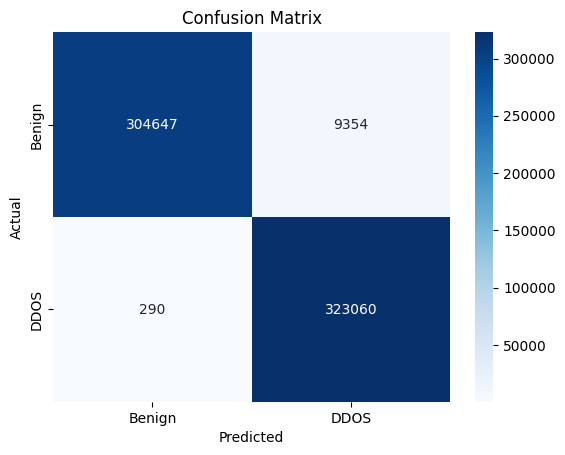

In [63]:
conf_matrix = confusion_matrix(test_y.reset_index(drop=True), y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Benign', 'DDOS'], yticklabels=['Benign', 'DDOS'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

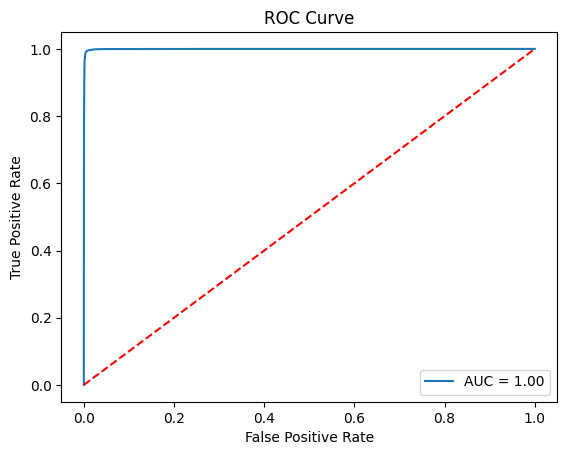

In [39]:
y_pred_proba = model.predict_proba(test_X[numerical_cols])[:,1]
fpr, tpr, _ = roc_curve(test_y.reset_index(drop=True), y_pred_proba)
auc = roc_auc_score(test_y.reset_index(drop=True), y_pred_proba)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [36]:
import joblib
joblib.dump(model, '/kaggle/working/log_reg_model.pkl')

['/kaggle/working/log_reg_model.pkl']

## Autoencoder

In [36]:
train_X.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
490518,0.898695,0.051714,0.352941,20/02/2018 03:01:31,0.030515,0.000029,0.000323,0.000115,0.000051,0.028981,...,0.0,0.0,0.797297,0.533333,0.007843,0.992157,0.673228,0.121569,0.262745,0.039216
273964,0.001221,0.832453,0.352941,16/02/2018 11:20:45 PM,0.036038,0.000013,0.000185,0.000094,0.000010,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
290214,0.001221,0.766198,0.352941,16/02/2018 11:24:01 PM,0.038713,0.000013,0.000185,0.000094,0.000013,0.040026,...,0.0,0.0,0.770270,0.121569,0.270588,0.098039,0.066929,0.858824,0.756863,0.078431
547447,0.802472,0.051714,0.352941,20/02/2018 09:28:37,0.018449,0.000026,0.000323,0.000116,0.000051,0.028981,...,0.0,0.0,0.945946,0.666667,0.211765,0.007843,0.673228,0.121569,0.258824,0.235294
167919,0.686564,0.001221,0.352941,16/02/2018 11:18:06 PM,0.000005,0.000003,0.000046,0.000000,0.000000,0.000000,...,0.0,0.0,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039


In [38]:
train_y.reset_index(drop=True).head()
pd.DataFrame(train_y).head()

,Label
490518,0
273964,1
290214,1
547447,0
167919,1


In [49]:
# train_X_benign = train_X[pd.DataFrame(train_y).reset_index(drop=True)["Label"]==0].reset_index(drop=True)  # TODO: Why this doesn't work??
train_X_benign = train_X[pd.DataFrame(train_y)["Label"]==0].reset_index(drop=True)[numerical_cols]
train_X_benign.isna().any(axis=1).sum()

0

In [50]:
train_X_benign.head()

,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Idle Max,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4
0,0.898695,0.051714,0.352941,0.030515,0.000029,0.000323,0.000115,0.000051,0.028981,0.000000,...,0.0,0.0,0.797297,0.533333,0.007843,0.992157,0.673228,0.121569,0.262745,0.039216
1,0.802472,0.051714,0.352941,0.018449,0.000026,0.000323,0.000116,0.000051,0.028981,0.000000,...,0.0,0.0,0.945946,0.666667,0.211765,0.007843,0.673228,0.121569,0.258824,0.235294
2,0.927123,0.051714,0.352941,0.029108,0.000032,0.000323,0.000116,0.000051,0.028981,0.000000,...,0.0,0.0,0.617117,0.788235,0.713725,0.070588,0.673228,0.121569,0.254902,0.423529
3,0.813626,0.000809,1.000000,0.000002,0.000003,0.000046,0.000004,0.000002,0.001755,0.027853,...,0.0,0.0,0.770270,0.121569,0.258824,0.164706,0.673228,0.121569,0.000000,0.007843
4,0.842344,0.051714,0.352941,0.015341,0.000026,0.000323,0.000115,0.000051,0.028981,0.000000,...,0.0,0.0,0.018018,0.737255,0.533333,0.180392,0.673228,0.121569,0.258824,0.101961


In [51]:
import torch
import torch.nn as nn
import torch.optim as optim

In [52]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim): # x -> x' -> x'' 
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.SELU(),
            nn.Linear(64, 32),
            nn.SELU(),
            nn.Linear(32, 8),
            nn.SELU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(8, 32),
            nn.SELU(),
            nn.Linear(32, 64),
            nn.SELU(),
            nn.Linear(64, input_dim),
            nn.SELU()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [53]:
input_dim = train_X_benign.shape[1]
model = Autoencoder(input_dim)
criterion = nn.L1Loss()
optimizer = optim.RMSprop(model.parameters(), lr=0.0001)

In [ ]:
# train_X_backup = train_X.copy()
# test_X_backup = test_X.copy()
# train_y_backup = train_y.copy()
# test_y_backup = test_y.copy()
# train_X_benign_backup = train_X_benign.copy()

# train_X = train_X_backup.copy()
# test_X = test_X_backup.copy()
# train_y = train_y_backup.copy()
# test_y = test_y_backup.copy()
# train_X_benign = train_X_benign_backup.copy()

In [57]:
if not isinstance(train_X, torch.Tensor):
    train_X = torch.FloatTensor(train_X[numerical_cols].values)
if not isinstance(train_y, torch.Tensor):
    train_y = torch.LongTensor(train_y.values)
if not isinstance(test_X, torch.Tensor):
    test_X = torch.FloatTensor(test_X[numerical_cols].values)
if not isinstance(test_y, torch.Tensor):
    test_y = torch.LongTensor(test_y.values)
if not isinstance(train_X_benign, torch.Tensor):
    train_X_benign = torch.FloatTensor(train_X_benign.values)

In [58]:
print(type(train_X))
print(type(train_y))
print(type(test_X))
print(type(test_y))
print(type(train_X_benign))

<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [105]:
from torch.utils.data import DataLoader, TensorDataset

train_loader = DataLoader(TensorDataset(train_X_benign), batch_size=32, shuffle=True)
epochs = 30

In [60]:
epoch_losses = []
reconstruction_losses_last_epoch = [] 
for epoch in range(epochs):
    model.train()   # set the model to training mode 
    total_loss = 0
    # using mini batch gradient descent
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()    # reset the gradients for each batch
        outputs = model(inputs)  # forward pass
        loss = criterion(outputs, inputs)    
        loss.backward()     # backward pass
        optimizer.step()    # update the weights
        total_loss += loss.item()

        # Track individual sample reconstruction losses only in the last epoch
        if epoch == epochs - 1:  # Collect only for the last epoch
            reconstruction_losses_last_epoch.extend(loss.item() for _ in range(len(inputs)))
            
    epoch_loss = total_loss/len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}') 
print("Autoencoder training complete")

Epoch 1/30, Loss: 0.0415
Epoch 2/30, Loss: 0.0316
Epoch 3/30, Loss: 0.0292
Epoch 4/30, Loss: 0.0275
Epoch 5/30, Loss: 0.0250
Epoch 6/30, Loss: 0.0236
Epoch 7/30, Loss: 0.0217
Epoch 8/30, Loss: 0.0204
Epoch 9/30, Loss: 0.0199
Epoch 10/30, Loss: 0.0196
Epoch 11/30, Loss: 0.0193
Epoch 12/30, Loss: 0.0189
Epoch 13/30, Loss: 0.0184
Epoch 14/30, Loss: 0.0181
Epoch 15/30, Loss: 0.0178
Epoch 16/30, Loss: 0.0176
Epoch 17/30, Loss: 0.0174
Epoch 18/30, Loss: 0.0173
Epoch 19/30, Loss: 0.0171
Epoch 20/30, Loss: 0.0170
Epoch 21/30, Loss: 0.0169
Epoch 22/30, Loss: 0.0168
Epoch 23/30, Loss: 0.0167
Epoch 24/30, Loss: 0.0166
Epoch 25/30, Loss: 0.0165
Epoch 26/30, Loss: 0.0164
Epoch 27/30, Loss: 0.0163
Epoch 28/30, Loss: 0.0162
Epoch 29/30, Loss: 0.0162
Epoch 30/30, Loss: 0.0161


In [100]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

reconstruction_losses_last_epoch = np.array(reconstruction_losses_last_epoch)

mean_loss = np.mean(reconstruction_losses_last_epoch)
std_loss = np.std(reconstruction_losses_last_epoch)

threshold = 1 * mean_loss + 2.5 * std_loss # Define threshold to have the highest recall possible. 

print(f"Anomaly Detection Threshold: {threshold}")

Anomaly Detection Threshold: 0.02195850705973381


In [101]:
model.eval()
reconstruction_errors = []
test_labels = test_y.numpy()

with torch.no_grad():
    outputs = model(test_X)
    reconstruction_errors = torch.mean(torch.abs(outputs - test_X), dim=1).numpy()

predicted_labels = (reconstruction_errors > threshold).astype(int)

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [102]:
accuracy = accuracy_score(test_labels, predicted_labels)
precision = precision_score(test_labels, predicted_labels)
recall = recall_score(test_labels, predicted_labels)
f1 = f1_score(test_labels, predicted_labels)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8652
Precision: 0.7901
Recall: 1.0000
F1 Score: 0.8827


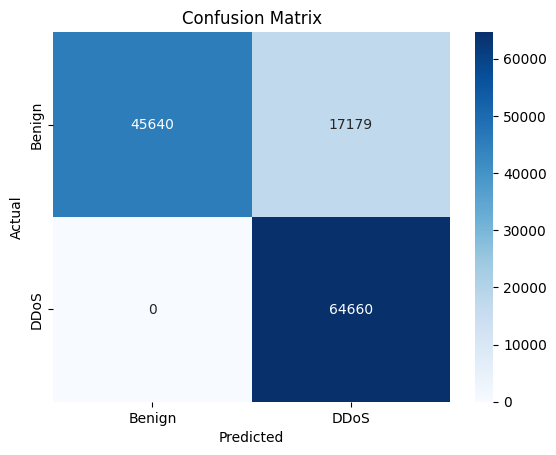

In [103]:
cm = confusion_matrix(test_labels, predicted_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'DDoS'], yticklabels=['Benign', 'DDoS'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [104]:
torch.save(model, "/kaggle/working/autoencoder.pt")

## LSTM

In [23]:
# Scaled data loading
train_scaled_X = pd.read_parquet("train_scaled_X.parquet")
test_scaled_X = pd.read_parquet("test_scaled_X.parquet")
train_scaled_y_df = pd.read_parquet("train_scaled_y.parquet")
test_scaled_y_df = pd.read_parquet("test_scaled_y.parquet")

# DF to Series conversion (as this is the default type of y)
train_scaled_y = train_scaled_y_df['Label']
test_scaled_y = test_scaled_y_df['Label']

print("Files loaded successfully")

Files loaded successfully


For now let's consider the training set as our only data source and train the LSTM on it

### merge y to X

In [24]:
data = train_scaled_X.copy()
data['Label'] = train_scaled_y.copy()
data.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
126586,0.833799,0.001221,0.352941,20/02/2018 10:56:14,9.352375e-03,0.000016,0.000185,0.000003,0.000031,0.002315,...,0.000000,0.076577,0.858824,0.035294,0.003922,0.673228,0.121569,0.270588,0.098039,1
92710,0.001221,0.849559,0.352941,22/02/2018 12:12:13 AM,4.050500e-04,0.000022,0.000139,0.000160,0.000009,0.108218,...,0.000000,0.770270,0.121569,0.270588,0.109804,0.066929,0.854902,0.450980,0.235294,1
442434,0.946258,0.000809,1.000000,20/02/2018 03:48:13,5.116667e-06,0.000005,0.000046,0.000005,0.000002,0.003704,...,0.000000,0.770270,0.121569,0.262745,0.392157,0.673228,0.121569,0.000000,0.007843,0
161226,0.535927,0.001221,0.352941,16/02/2018 11:17:50 PM,2.274250e-04,0.000005,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
564589,0.829282,0.006760,0.352941,20/02/2018 02:59:21,8.761284e-01,0.000055,0.000647,0.000115,0.000056,0.031134,...,0.384567,0.770270,0.121569,0.262745,0.223529,0.507874,0.827451,0.149020,0.568627,0
330531,0.917983,0.000809,1.000000,04/07/2017 12:38:41 AM,5.655084e-01,0.000005,0.000139,0.000009,0.000009,0.006134,...,0.563733,0.860360,0.658824,0.039216,0.011765,0.751969,0.658824,0.039216,0.003922,0
165129,0.529854,0.001221,0.352941,16/02/2018 11:18:09 PM,5.505750e-04,0.000011,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
40810,0.913481,0.001221,0.352941,22/02/2018 12:06:27 AM,1.463333e-05,0.000005,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.854902,0.450980,0.235294,0.673228,0.121569,0.270588,0.109804,1
584594,0.758068,0.001221,0.352941,20/02/2018 09:26:23,4.582913e-01,0.000011,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.770270,0.121569,0.262745,0.109804,0.661417,0.996078,0.662745,0.996078,0
509012,0.006790,0.991852,0.352941,20/02/2018 04:22:31,2.083333e-07,0.000011,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.770270,0.121569,0.262745,0.427451,0.783465,0.631373,0.925490,0.262745,0


In [25]:
def parse_mixed_formats(timestamp):
    try:
        # Try parsing with AM/PM (12-hour format)
        return pd.to_datetime(timestamp, format="%d/%m/%Y %I:%M:%S %p", dayfirst=True)
    except ValueError:
        try:
            # Try parsing without AM/PM (24-hour format)
            return pd.to_datetime(timestamp, format="%d/%m/%Y %H:%M:%S", dayfirst=True)
        except ValueError:
            return pd.NaT  # Return NaT for invalid formats
            
data['Timestamp'] = data['Timestamp'].apply(parse_mixed_formats)
print("Done TS parsing")

Done TS parsing


In [26]:
data.head(10)

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
126586,0.833799,0.001221,0.352941,2018-02-20 10:56:14,9.352375e-03,0.000016,0.000185,0.000003,0.000031,0.002315,...,0.000000,0.076577,0.858824,0.035294,0.003922,0.673228,0.121569,0.270588,0.098039,1
92710,0.001221,0.849559,0.352941,2018-02-22 00:12:13,4.050500e-04,0.000022,0.000139,0.000160,0.000009,0.108218,...,0.000000,0.770270,0.121569,0.270588,0.109804,0.066929,0.854902,0.450980,0.235294,1
442434,0.946258,0.000809,1.000000,2018-02-20 03:48:13,5.116667e-06,0.000005,0.000046,0.000005,0.000002,0.003704,...,0.000000,0.770270,0.121569,0.262745,0.392157,0.673228,0.121569,0.000000,0.007843,0
161226,0.535927,0.001221,0.352941,2018-02-16 23:17:50,2.274250e-04,0.000005,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
564589,0.829282,0.006760,0.352941,2018-02-20 02:59:21,8.761284e-01,0.000055,0.000647,0.000115,0.000056,0.031134,...,0.384567,0.770270,0.121569,0.262745,0.223529,0.507874,0.827451,0.149020,0.568627,0
330531,0.917983,0.000809,1.000000,2017-07-04 00:38:41,5.655084e-01,0.000005,0.000139,0.000009,0.000009,0.006134,...,0.563733,0.860360,0.658824,0.039216,0.011765,0.751969,0.658824,0.039216,0.003922,0
165129,0.529854,0.001221,0.352941,2018-02-16 23:18:09,5.505750e-04,0.000011,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.858824,0.756863,0.078431,0.673228,0.121569,0.270588,0.098039,1
40810,0.913481,0.001221,0.352941,2018-02-22 00:06:27,1.463333e-05,0.000005,0.000046,0.000000,0.000000,0.000000,...,0.000000,0.076577,0.854902,0.450980,0.235294,0.673228,0.121569,0.270588,0.109804,1
584594,0.758068,0.001221,0.352941,2018-02-20 09:26:23,4.582913e-01,0.000011,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.770270,0.121569,0.262745,0.109804,0.661417,0.996078,0.662745,0.996078,0
509012,0.006790,0.991852,0.352941,2018-02-20 04:22:31,2.083333e-07,0.000011,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.770270,0.121569,0.262745,0.427451,0.783465,0.631373,0.925490,0.262745,0


In [27]:
# Check for pd.NaT in Timestamp column
print(data['Timestamp'].isnull().sum())

0


In [28]:
# save 
data.to_parquet("lstm_data.parquet")

print("Saving complete")

Saving complete


In [2]:
# load
import pandas as pd
data = pd.read_parquet("/kaggle/input/lstm-dataset/lstm_data.parquet")

In [3]:
data = data.sort_values(by='Timestamp')
data.head()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,...,Idle Min,Src IP Octet1,Src IP Octet2,Src IP Octet3,Src IP Octet4,Dst IP Octet1,Dst IP Octet2,Dst IP Octet3,Dst IP Octet4,Label
3818,0.069261,0.001221,0.352941,2010-06-12 08:37:06,3.920033e-03,0.000011,0.000231,0.000016,0.000031,0.010532,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
2749,0.069459,0.001221,0.352941,2010-06-12 08:37:20,4.166667e-08,0.000005,0.000046,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
4502,0.069490,0.001221,0.352941,2010-06-12 08:37:21,8.734292e-03,0.000033,0.000601,0.000020,0.000436,0.013657,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
901,0.069551,0.001221,0.352941,2010-06-12 08:37:25,3.166667e-07,0.000005,0.000046,0.000000,0.000000,0.000000,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1
1674,0.069673,0.001221,0.352941,2010-06-12 08:37:43,4.140284e-03,0.000011,0.000277,0.000016,0.000089,0.010995,...,0.0,0.86036,0.658824,0.015686,0.462745,0.795276,0.286275,0.094118,0.294118,1


In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [15]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length  # Number of sequences

    def __getitem__(self, index):
        X = self.data.iloc[index:index + self.seq_length].drop(columns=['Label']).values
        y = self.data.iloc[index + self.seq_length]['Label']
        
        # Convert to tensors
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)  # Classification task
        
        return X_tensor, y_tensor


In [8]:
from sklearn.model_selection import train_test_split

# Load your dataset
df = data.copy()

# get feature count
features = df.drop(columns=['Label', 'Timestamp'])

# Split into train and test sets
train_data, test_data = train_test_split(df, test_size=0.95, stratify=df['Label'], random_state=42)

# Ensure data is sorted by timestamp
train_data = train_data.sort_values(by="Timestamp")
train_data = train_data.drop(columns=["Timestamp"])
test_data = test_data.sort_values(by="Timestamp")
test_data = test_data.drop(columns=["Timestamp"])

# Sequence length
seq_length = 50
batch_size = 32

# Create Dataset and DataLoader
train_dataset = NetworkTrafficDataset(train_data, seq_length)
test_dataset = NetworkTrafficDataset(test_data, seq_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

Training data size: 25495
Testing data size: 484418


In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # LSTM forward pass
        out = self.fc(out[:, -1, :])  # Take the output of the last time step
        return out


In [12]:
# Model parameters
input_size = len(features.columns)  # Number of features
hidden_size = 128
num_layers = 2
output_size = 2  # Binary classification (DDOS or not)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = LSTMModel(input_size, hidden_size, num_layers, output_size).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.005)

# Training loop config
num_epochs = 20
total_items = 0

# time specific imports and config
import pytz
import datetime
my_timezone = pytz.timezone("Asia/Colombo")

start_time = datetime.datetime.utcnow()
start_local = start_time.astimezone(my_timezone)
utc_now = datetime.datetime.utcnow()
local_now = utc_now.astimezone(my_timezone)
print(f"Training started at: {local_now.strftime('%a, %b %d %Y %H:%M:%S %Z')}")

# Loop
for epoch in range(num_epochs):
    lstm_model.train()
    total_loss = 0
    # epoch_start = time.time()  # Start time of the epoch

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = lstm_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_items += X_batch.size(0) 
        
    # epoch_end = time.time()  # End time of the epoch
    # epoch_duration = (epoch_end - epoch_start) / 60
    utc_now = datetime.datetime.utcnow()
    local_now = utc_now.astimezone(my_timezone)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}, Time: {local_now.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
    
# end_time = time.time()  # End time of the training
end_time = datetime.datetime.utcnow()
end_local = end_time.astimezone(my_timezone)
duration = end_time - start_time
total_seconds = duration.total_seconds()
minutes, seconds = divmod(int(total_seconds), 60)
# total_duration = (end_time - start_time) / 60  # Convert seconds to minutes
print("---")
print(f"\nTraining completed successfully")
print(f"Total training time: {minutes} mins, {seconds} seconds")
print(f"Training started at: {start_local.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
print(f"Training ended at: {end_local.strftime('%a, %b %d %Y %H:%M:%S %Z')}")
print("---")
print(f"Total items processed: {total_items}")

Training started at: Thu, Feb 27 2025 09:12:07 +0530
Epoch 1/20, Loss: 0.4053, Time: Thu, Feb 27 2025 09:12:39 +0530
Epoch 2/20, Loss: 0.1515, Time: Thu, Feb 27 2025 09:13:11 +0530
Epoch 3/20, Loss: 0.0988, Time: Thu, Feb 27 2025 09:13:42 +0530
Epoch 4/20, Loss: 0.0858, Time: Thu, Feb 27 2025 09:14:14 +0530
Epoch 5/20, Loss: 0.0795, Time: Thu, Feb 27 2025 09:14:46 +0530
Epoch 6/20, Loss: 0.0764, Time: Thu, Feb 27 2025 09:15:17 +0530
Epoch 7/20, Loss: 0.0749, Time: Thu, Feb 27 2025 09:15:49 +0530
Epoch 8/20, Loss: 0.0757, Time: Thu, Feb 27 2025 09:16:20 +0530
Epoch 9/20, Loss: 0.0750, Time: Thu, Feb 27 2025 09:16:52 +0530
Epoch 10/20, Loss: 0.0737, Time: Thu, Feb 27 2025 09:17:24 +0530
Epoch 11/20, Loss: 0.0754, Time: Thu, Feb 27 2025 09:17:56 +0530
Epoch 12/20, Loss: 0.0740, Time: Thu, Feb 27 2025 09:18:27 +0530
Epoch 13/20, Loss: 0.0735, Time: Thu, Feb 27 2025 09:18:59 +0530
Epoch 14/20, Loss: 0.0729, Time: Thu, Feb 27 2025 09:19:30 +0530
Epoch 15/20, Loss: 0.0752, Time: Thu, Feb 27 2

In [13]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, average_precision_score, confusion_matrix, 
                             roc_curve, precision_recall_curve, classification_report, 
                             matthews_corrcoef)

lstm_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = lstm_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# # Calculate accuracy
# accuracy = accuracy_score(all_labels, all_preds)
# print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Compute Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
mcc = matthews_corrcoef(all_labels, all_preds)  # Balanced metric for imbalanced data
roc_auc = roc_auc_score(all_labels, all_preds)
average_precision = average_precision_score(all_labels, all_preds)

# Confusion Matrix
conf_matrix = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = conf_matrix.ravel()

# Additional Metrics
specificity = tn / (tn + fp)  # True Negative Rate
false_positive_rate = fp / (fp + tn)  # 1 - Specificity
false_negative_rate = fn / (fn + tp)  # Miss Rate
fpr, tpr, _ = roc_curve(all_labels, all_preds)
precisions, recalls, _ = precision_recall_curve(all_labels, all_preds)

# Print Metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Average Precision Score: {average_precision:.4f}")
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")
print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")

print("\nClassification Report:\n", classification_report(all_labels, all_preds))
print("\nConfusion Matrix:\n", conf_matrix)

Accuracy: 95.41%
Precision: 0.9990
Recall (Sensitivity): 0.9106
Specificity (True Negative Rate): 0.9990
F1-score: 0.9527
ROC-AUC Score: 0.9548
Average Precision Score: 0.9551
Matthews Correlation Coefficient (MCC): 0.9121
False Positive Rate (FPR): 0.0010
False Negative Rate (FNR): 0.0894

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96    238446
           1       1.00      0.91      0.95    245922

    accuracy                           0.95    484368
   macro avg       0.96      0.95      0.95    484368
weighted avg       0.96      0.95      0.95    484368


Confusion Matrix:
 [[238215    231]
 [ 21981 223941]]
